In [1]:
import numpy as np
import awkward as ak
import glob
import uproot
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
i0s1_wildcard = '/global/cfs/cdirs/m3246/ZjetOmnifold/model_repository/zjets-unfolding/scratch_s2_*/weights/iteration_0_step_1.npz'
i1s2_wildcard = '/global/cfs/cdirs/m3246/ZjetOmnifold/model_repository/zjets-unfolding/scratch_s2_*/weights/iteration_1_step_2.npz'

In [3]:
# Get glob of files
i0s1_files = sorted(glob.glob(i0s1_wildcard))
i1s2_files = sorted(glob.glob(i1s2_wildcard))

In [22]:
# Get MC test set
f_mctest = uproot.open('../dataloc/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_test_Mar0723.root')
t_mctest = f_mctest['OmniTree']

In [47]:
# Get pass190 flags
pass190 = ak.to_numpy(t_mctest['pass190'].array())
truth_pass190 = ak.to_numpy(t_mctest['truth_pass190'].array())
good_evts = np.logical_and(pass190, truth_pass190)

In [51]:
# Load the info from the files
i0s1_test_weights = [np.load(f)['network_test'] for f in i0s1_files]
i0s1_test_weights = np.stack(i0s1_test_weights, axis=0)
i1s2_test_weights = [np.load(f)['network_test'] for f in i1s2_files]
i1s2_test_weights = np.stack(i1s2_test_weights, axis=0)

i0s1_final_test_weights = [np.load(f)['test'] for f in i0s1_files]
i0s1_final_test_weights = np.stack(i0s1_final_test_weights, axis=0)
i1s2_final_test_weights = [np.load(f)['test'] for f in i1s2_files]
i1s2_final_test_weights = np.stack(i1s2_final_test_weights, axis=0)

In [52]:
# Load the raw outputs from each of the files
i0s1_test_raw_outputs = [np.load(f)['raw_test_output'] for f in i0s1_files]
i0s1_test_raw_outputs = np.stack(i0s1_test_raw_outputs, axis=0)
i1s2_test_raw_outputs = [np.load(f)['raw_test_output'] for f in i1s2_files]
i1s2_test_raw_outputs = np.stack(i1s2_test_raw_outputs, axis=0)

In [53]:
# Take mean and median of weights and raw inputs
i0s1_test_weights_mean = np.mean(i0s1_test_weights, axis=0)
i0s1_test_weights_median = np.median(i0s1_test_weights, axis=0)
i1s2_test_weights_mean = np.mean(i1s2_test_weights, axis=0)
i1s2_test_weights_median = np.median(i1s2_test_weights, axis=0)

i0s1_final_test_weights_mean = np.mean(i0s1_final_test_weights, axis=0)
i0s1_final_test_weights_median = np.median(i0s1_final_test_weights, axis=0)
i1s2_final_test_weights_mean = np.mean(i1s2_final_test_weights, axis=0)
i1s2_final_test_weights_median = np.median(i1s2_final_test_weights, axis=0)

i0s1_test_raw_outputs_mean = np.mean(i0s1_test_raw_outputs, axis=0)
i0s1_test_raw_outputs_median = np.median(i0s1_test_raw_outputs, axis=0)
i1s2_test_raw_outputs_mean = np.mean(i1s2_test_raw_outputs, axis=0)
i1s2_test_raw_outputs_median = np.median(i1s2_test_raw_outputs, axis=0)

In [56]:
# Save mean and median final weights to .npy files
np.savez('../i0s1_trig_test_weights_mean.npz', test=i0s1_final_test_weights_mean)
np.savez('../i0s1_trig_test_weights_median.npz', test=i0s1_final_test_weights_median)
np.savez('../i1s2_trig_test_weights_mean.npz', test=i1s2_final_test_weights_mean)
np.savez('../i1s2_trig_test_weights_median.npz', test=i1s2_final_test_weights_median)

In [69]:
# Take index of dispersion of network weights and raw outputs
i0s1_test_weights_var = np.var(i0s1_test_weights, axis=0) / np.mean(i0s1_test_weights, axis=0)
i1s2_test_weights_var = np.var(i1s2_test_weights, axis=0) / np.mean(i1s2_test_weights, axis=0)

i0s1_test_raw_outputs_var = np.var(i0s1_test_raw_outputs, axis=0) / np.mean(i0s1_test_raw_outputs, axis=0)
i1s2_test_raw_outputs_var = np.var(i1s2_test_raw_outputs, axis=0) / np.mean(i1s2_test_raw_outputs, axis=0)

In [75]:
# Get some observables from the test set
p190 = ak.to_numpy(t_mctest['pass190'].array())
truth_p190 = ak.to_numpy(t_mctest['truth_pass190'].array())
mj2 = ak.to_numpy(t_mctest['m_trackj2'].array())
phi2 = ak.to_numpy(t_mctest['phi_l1'].array())

# Get number of tracks in each event
track_pt = t_mctest['pT_tracks'].array()
ntracks = ak.to_numpy(ak.num(track_pt, axis=1))

In [77]:
# Filter observables
reco_mj2 = mj2[p190 == 1]
reco_phi2 = phi2[p190 == 1]
reco_ntracks = ntracks[p190 == 1]

truth_mj2 = mj2[truth_p190 == 1]
truth_phi2 = phi2[truth_p190 == 1]
truth_ntracks = ntracks[truth_p190 == 1]

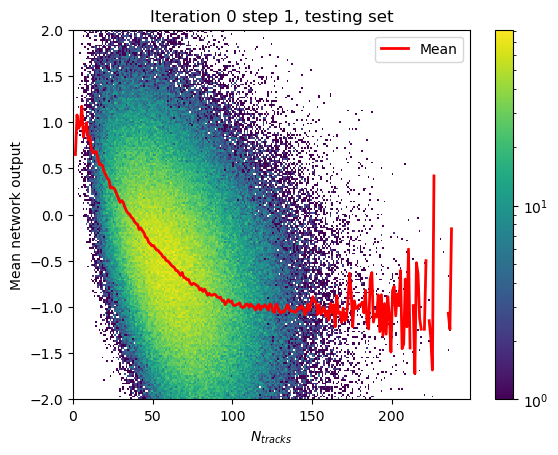

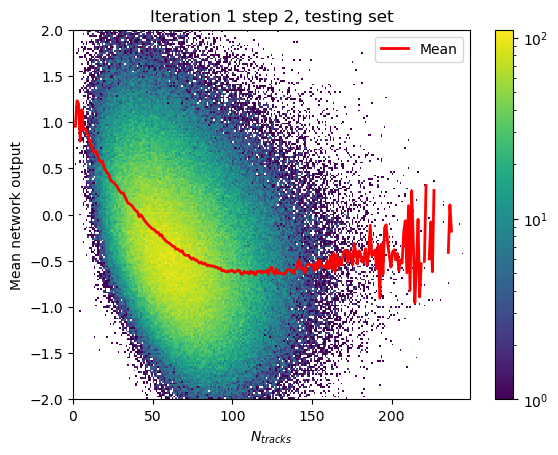

In [78]:
# Make a 2D histograms with profile of the raw output against the number of tracks
mean_var = stats.binned_statistic(reco_ntracks, i0s1_test_raw_outputs_mean, bins=np.arange(0, 250, 1), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(reco_ntracks, i0s1_test_raw_outputs_mean, bins=[np.arange(0, 250, 1), np.linspace(-2, 2, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
# plt.ylim(bottom=0.001)
# plt.yscale('log')
plt.xlabel(r'$N_{tracks}$')
plt.ylabel(r'Mean network output')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

mean_var = stats.binned_statistic(truth_ntracks, i1s2_test_raw_outputs_mean, bins=np.arange(0, 250, 1), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(truth_ntracks, i1s2_test_raw_outputs_mean, bins=[np.arange(0, 250, 1), np.linspace(-2, 2, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
# plt.ylim(bottom=0.001)
# plt.yscale('log')
plt.xlabel(r'$N_{tracks}$')
plt.ylabel(r'Mean network output')
plt.title('Iteration 1 step 2, testing set')
plt.colorbar()
plt.legend()
plt.show()

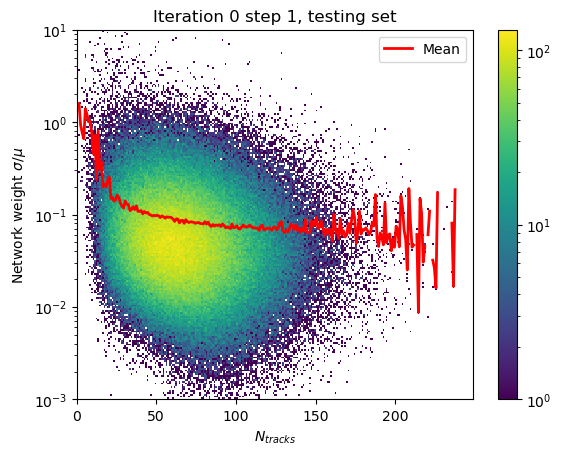

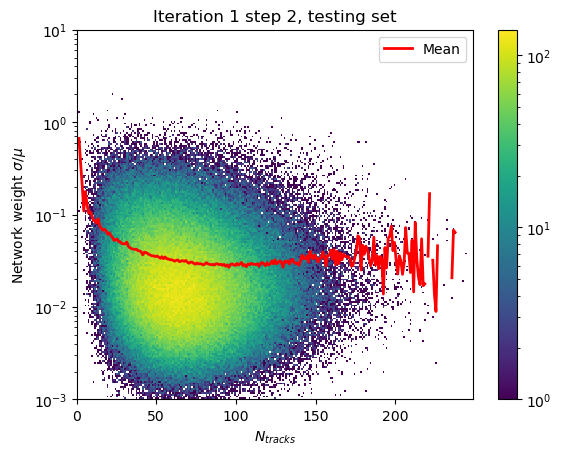

In [80]:
# Make a 2D histogram with profile of the weight variance against the number of tracks
mean_var = stats.binned_statistic(reco_ntracks, i0s1_test_weights_var, bins=np.arange(0, 250, 1), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(reco_ntracks, i0s1_test_weights_var, bins=[np.arange(0, 250, 1), np.logspace(-3, 1, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
plt.ylim(bottom=0.001)
plt.yscale('log')
plt.xlabel(r'$N_{tracks}$')
plt.ylabel(r'Network weight $\sigma / \mu$')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

mean_var = stats.binned_statistic(truth_ntracks, i1s2_test_weights_var, bins=np.arange(0, 250, 1), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(truth_ntracks, i1s2_test_weights_var, bins=[np.arange(0, 250, 1), np.logspace(-3, 1, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
plt.ylim(bottom=0.001)
plt.yscale('log')
plt.xlabel(r'$N_{tracks}$')
plt.ylabel(r'Network weight $\sigma / \mu$')
plt.title('Iteration 1 step 2, testing set')
plt.colorbar()
plt.legend()
plt.show()

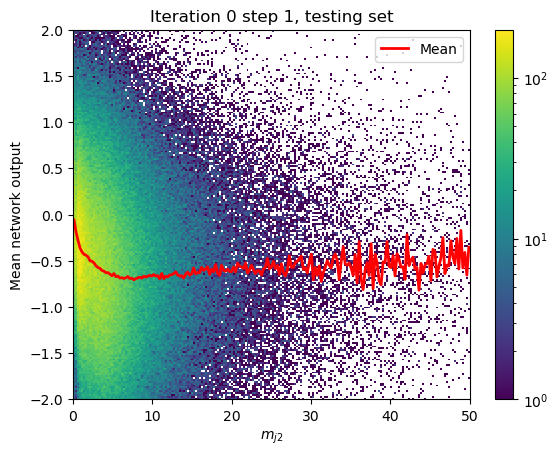

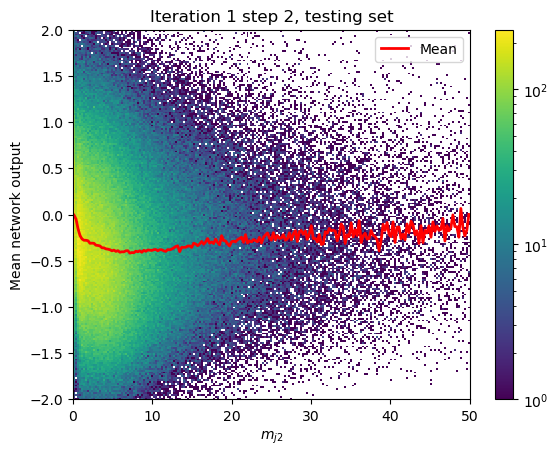

In [82]:
# Make a 2D histogram with profile of the raw output against the mass of the sub-leading jet
mean_var = stats.binned_statistic(reco_mj2, i0s1_test_raw_outputs_mean, bins=np.linspace(0, 50, 200), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(reco_mj2, i0s1_test_raw_outputs_mean, bins=[np.linspace(0, 50, 200), np.linspace(-2, 2, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
# plt.ylim(bottom=0.001)
# plt.yscale('log')
plt.xlabel(r'$m_{j2}$')
plt.ylabel(r'Mean network output')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

mean_var = stats.binned_statistic(truth_mj2, i1s2_test_raw_outputs_mean, bins=np.linspace(0, 50, 200), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(truth_mj2, i1s2_test_raw_outputs_mean, bins=[np.linspace(0, 50, 200), np.linspace(-2, 2, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
# plt.ylim(bottom=0.001)
# plt.yscale('log')
plt.xlabel(r'$m_{j2}$')
plt.ylabel(r'Mean network output')
plt.title('Iteration 1 step 2, testing set')
plt.colorbar()
plt.legend()
plt.show()

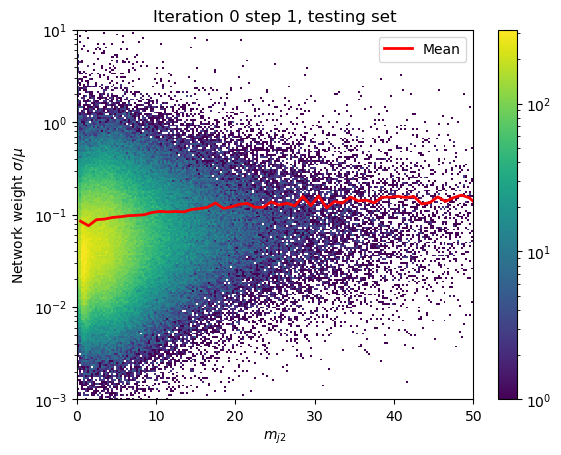

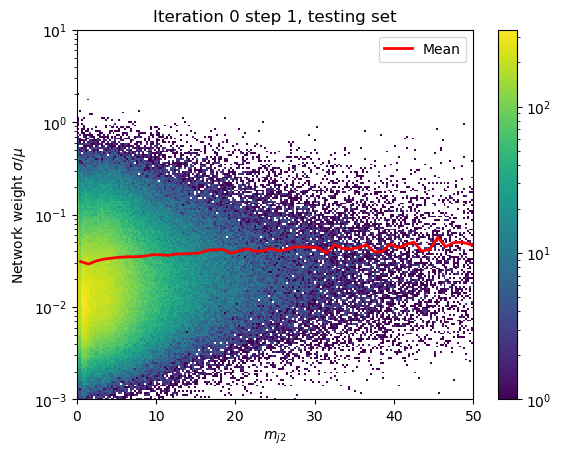

In [84]:
# Make a 2D histogram with profile of the weight variance against the mass of the sub-leading jet
mean_var = stats.binned_statistic(reco_mj2, i0s1_test_weights_var, bins=np.arange(0, 250, 1), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(reco_mj2, i0s1_test_weights_var, bins=[np.linspace(0, 50, 200), np.logspace(-3, 1, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
plt.ylim(bottom=0.001)
plt.yscale('log')
plt.xlabel(r'$m_{j2}$')
plt.ylabel(r'Network weight $\sigma / \mu$')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

mean_var = stats.binned_statistic(truth_mj2, i1s2_test_weights_var, bins=np.arange(0, 250, 1), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(truth_mj2, i1s2_test_weights_var, bins=[np.linspace(0, 50, 200), np.logspace(-3, 1, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
plt.ylim(bottom=0.001)
plt.yscale('log')
plt.xlabel(r'$m_{j2}$')
plt.ylabel(r'Network weight $\sigma / \mu$')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

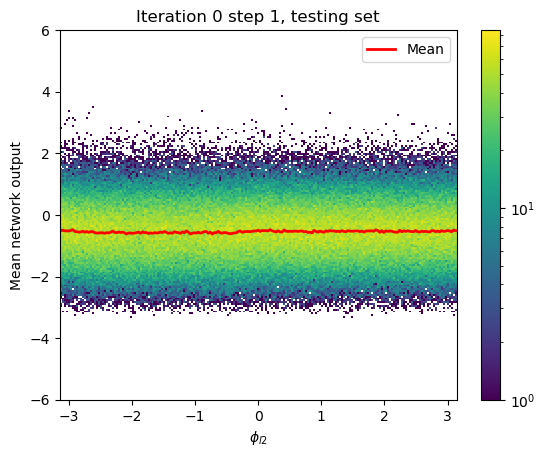

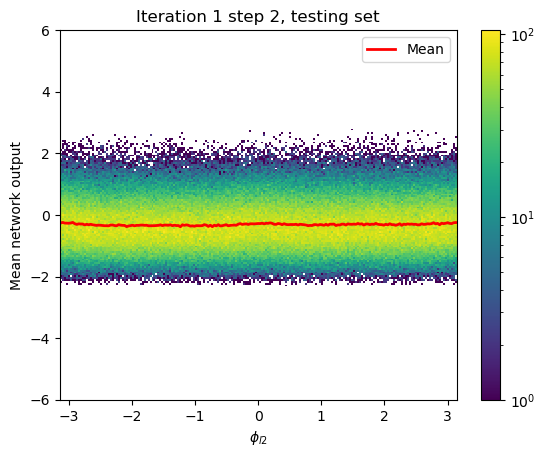

In [85]:
# Make a 2D histogram with profile of the raw output against the leading muon phi
mean_var = stats.binned_statistic(reco_phi2, i0s1_test_raw_outputs_mean, bins=np.linspace(-np.pi, np.pi, 200), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(reco_phi2, i0s1_test_raw_outputs_mean, bins=[np.linspace(-np.pi, np.pi, 200), np.linspace(-6, 6, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
# plt.ylim(bottom=0.001)
# plt.yscale('log')
plt.xlabel(r'$\phi_{l2}$')
plt.ylabel(r'Mean network output')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

mean_var = stats.binned_statistic(truth_phi2, i1s2_test_raw_outputs_mean, bins=np.linspace(-np.pi, np.pi, 200), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(truth_phi2, i1s2_test_raw_outputs_mean, bins=[np.linspace(-np.pi, np.pi, 200), np.linspace(-6, 6, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
# plt.ylim(bottom=0.001)
# plt.yscale('log')
plt.xlabel(r'$\phi_{l2}$')
plt.ylabel(r'Mean network output')
plt.title('Iteration 1 step 2, testing set')
plt.colorbar()
plt.legend()
plt.show()

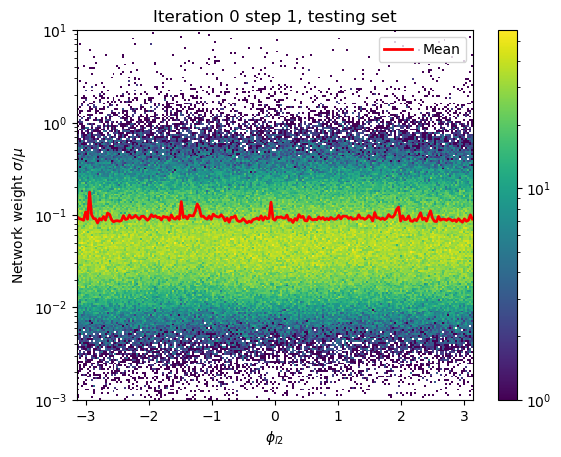

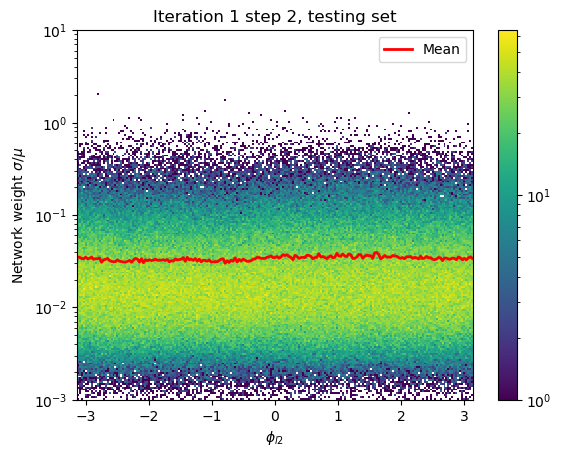

In [86]:
# Make a 2D histogram with profile of the weight variance against the phi of the leading muon
mean_var = stats.binned_statistic(reco_phi2, i0s1_test_weights_var, bins=np.linspace(-np.pi, np.pi, 200), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(reco_phi2, i0s1_test_weights_var, bins=[np.linspace(-np.pi, np.pi, 200), np.logspace(-3, 1, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
plt.ylim(bottom=0.001)
plt.yscale('log')
plt.xlabel(r'$\phi_{l2}$')
plt.ylabel(r'Network weight $\sigma / \mu$')
plt.title('Iteration 0 step 1, testing set')
plt.colorbar()
plt.legend()
plt.show()

mean_var = stats.binned_statistic(truth_phi2, i1s2_test_weights_var, bins=np.linspace(-np.pi, np.pi, 200), statistic='mean')
bin_centers = 0.5*(mean_var.bin_edges[:-1] + mean_var.bin_edges[1:])

plt.hist2d(truth_phi2, i1s2_test_weights_var, bins=[np.linspace(-np.pi, np.pi, 200), np.logspace(-3, 1, 200)], norm=plt.cm.colors.LogNorm())
plt.plot(bin_centers, mean_var.statistic, color='red', linewidth=2, label='Mean')
plt.ylim(bottom=0.001)
plt.yscale('log')
plt.xlabel(r'$\phi_{l2}$')
plt.ylabel(r'Network weight $\sigma / \mu$')
plt.title('Iteration 1 step 2, testing set')
plt.colorbar()
plt.legend()
plt.show()